# Tikhonov Regularisation for Ill-Posed Inverse Problems

## Objective

Recover an unknown source profile from noisy measurements using Tikhonov regularisation.

## Technologies

- Python
- NumPy
- Matplotlib

## Concepts

- Inverse Problems
- Regularisation
- Least Squares
- L-Curve Analysis
- Numerical Linear Algebra

## Applications

- Methane Leak Quantification
- Medical Imaging
- Geophysical Inversion
- Financial Signal Recovery

## Author

Parag Gupta

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
n_sources = 30
n_sensors = 20

x_sources = np.linspace(0,1,n_sources)
x_sensors = np.linspace(0.05,0.95,n_sensors)

sigma = 0.12

A = np.zeros((n_sensors,n_sources))

for i,xs in enumerate(x_sensors):
    for j,xq in enumerate(x_sources):
        A[i,j] = np.exp(
            -((xs-xq)**2)/(2*sigma**2)
        )

print(A.shape)

(20, 30)


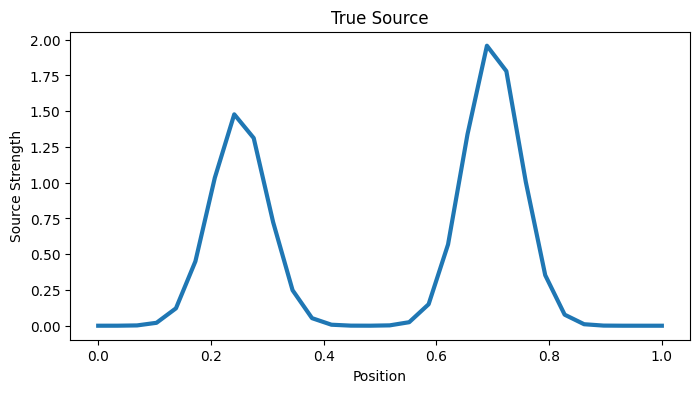

In [4]:
q_true = (
    1.5*np.exp(-((x_sources-0.25)**2)/0.005)
    +
    2.0*np.exp(-((x_sources-0.70)**2)/0.005)
)

plt.figure(figsize=(8,4))

plt.plot(
    x_sources,
    q_true,
    linewidth=3
)

plt.title("True Source")

plt.xlabel("Position")

plt.ylabel("Source Strength")

plt.show()

In [5]:
L_clean = A @ q_true

noise_level = 0.05

noise = (
    noise_level
    * np.max(np.abs(L_clean))
    * np.random.randn(n_sensors)
)

L_noisy = L_clean + noise

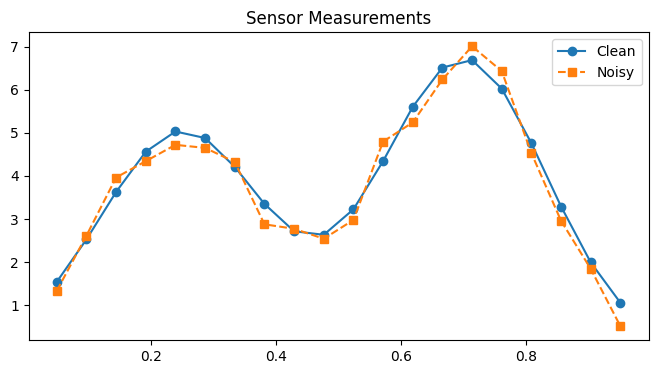

In [6]:
plt.figure(figsize=(8,4))

plt.plot(
    x_sensors,
    L_clean,
    'o-',
    label="Clean"
)

plt.plot(
    x_sensors,
    L_noisy,
    's--',
    label="Noisy"
)

plt.legend()

plt.title("Sensor Measurements")

plt.show()

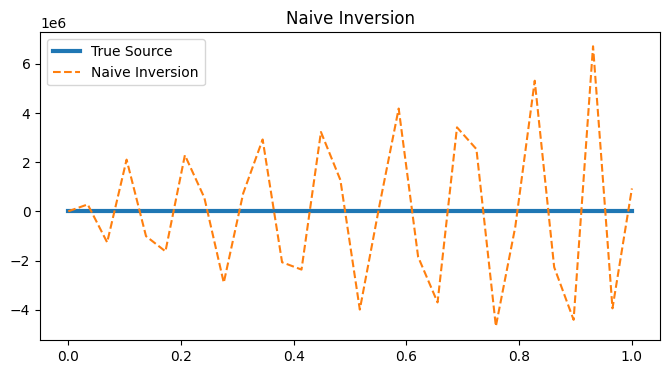

In [7]:
q_naive = np.linalg.pinv(A) @ L_noisy

plt.figure(figsize=(8,4))

plt.plot(
    x_sources,
    q_true,
    linewidth=3,
    label="True Source"
)

plt.plot(
    x_sources,
    q_naive,
    '--',
    label="Naive Inversion"
)

plt.legend()

plt.title("Naive Inversion")

plt.show()

In [8]:
def tikhonov(A,L,lam):

    ATA = A.T @ A

    ATL = A.T @ L

    n = A.shape[1]

    q = np.linalg.solve(
        ATA + lam*np.eye(n),
        ATL
    )

    return q

In [9]:
lam = 0.01

q_reg = tikhonov(
    A,
    L_noisy,
    lam
)

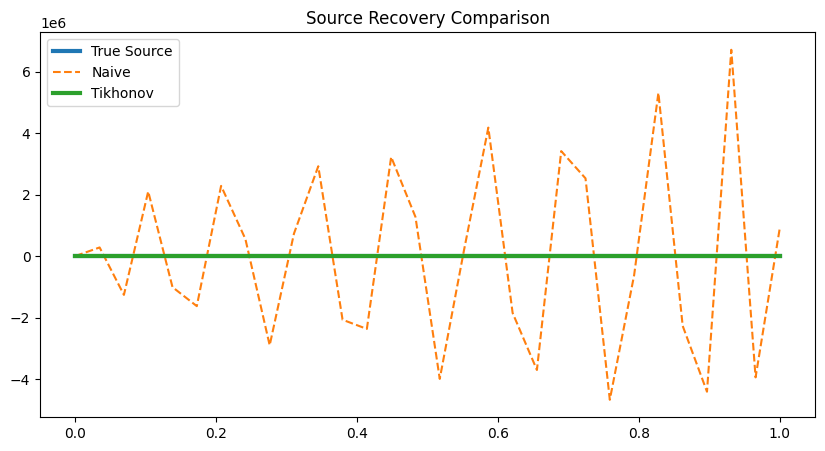

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    x_sources,
    q_true,
    linewidth=3,
    label="True Source"
)

plt.plot(
    x_sources,
    q_naive,
    '--',
    label="Naive"
)

plt.plot(
    x_sources,
    q_reg,
    linewidth=3,
    label="Tikhonov"
)

plt.legend()

plt.title(
    "Source Recovery Comparison"
)

plt.show()

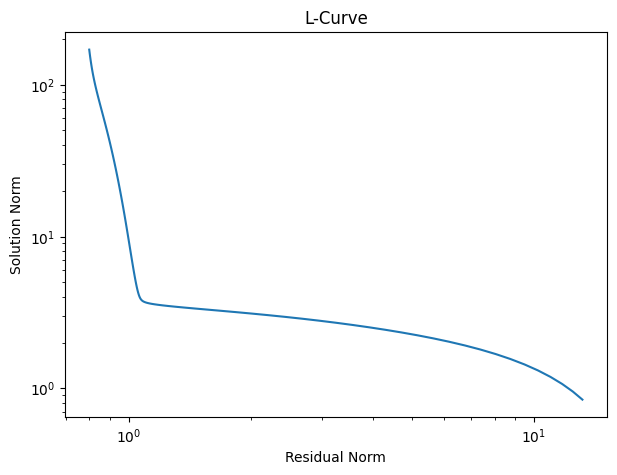

In [11]:
lambdas = np.logspace(-6,2,100)

residuals = []

solutions = []

for lam in lambdas:

    q = tikhonov(
        A,
        L_noisy,
        lam
    )

    residuals.append(
        np.linalg.norm(A@q-L_noisy)
    )

    solutions.append(
        np.linalg.norm(q)
    )

plt.figure(figsize=(7,5))

plt.loglog(
    residuals,
    solutions
)

plt.xlabel(
    "Residual Norm"
)

plt.ylabel(
    "Solution Norm"
)

plt.title(
    "L-Curve"
)

plt.show()

In [12]:
error = (
    np.linalg.norm(q_reg-q_true)
    /
    np.linalg.norm(q_true)
)

print(
    "Relative Error:",
    round(error*100,2),
    "%"
)

Relative Error: 57.99 %
